# Wine 데이터
 https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

In [1]:
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# 저장 경로 지정
save_path = "./winequality-red.csv"

urllib.request.urlretrieve(url, save_path)
print("다운로드 완료:", os.path.abspath(save_path))

다운로드 완료: /home/ubuntu/projects/winequality-red.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1774570879.922041    1459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774570880.233050    1459 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774570881.630462    1459 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
redwine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
redwine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
redwine.describe

<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.0

In [5]:
X, y = redwine.iloc[:,:-1], redwine.iloc[:, -1]

In [6]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [7]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [8]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [9]:
y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [10]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

# y의 라벨인코딩 3~8 -> 0~5

In [11]:
from  sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
np.unique(y_encoded)

array([0, 1, 2, 3, 4, 5])

# 학습/테스트 데이터 분할

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [13]:
X_train.shape, X_test.shape

((1279, 11), (320, 11))

In [14]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [15]:
X_train_scaled_ary = np.array(X_train_scaled)
X_test_scaled_ary = np.array(X_test_scaled)

In [16]:
type(X_train_scaled_ary)

numpy.ndarray

In [17]:
from tensorflow.keras.utils import to_categorical

# y_train 원-핫 인코딩
y_train_ohe = to_categorical(y_train)
y_test_ohe  = to_categorical(y_test)

print("변환 전:", y_train.shape)       # (1199,)
print("변환 후:", y_train_ohe.shape)   # (1199, 6)

변환 전: (1279,)
변환 후: (1279, 6)


In [28]:
model.evaluate(X_test_scaled_ary, y_test_ohe)

I0000 00:00:1774577066.508372    2431 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5969 - loss: 0.9486


[0.9485853314399719, 0.596875011920929]

# 한글폰트

In [22]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

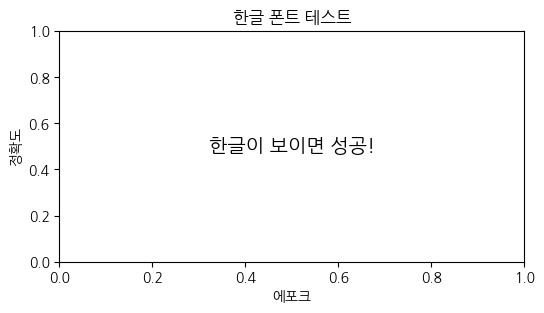

In [23]:
#한글 테스트
plt.figure(figsize=(6, 3))
plt.title('한글 폰트 테스트')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.text(0.5, 0.5, '한글이 보이면 성공!',
         ha='center', va='center', fontsize=14)
plt.show()

# 모델 생성

In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(11,))) #입력층

model.add(Dense(100, activation='sigmoid')) #은닉층1
model.add(Dropout(0.2))

model.add(Dense(200, activation='relu')) #은닉층2
model.add(Dropout(0.4))

model.add(Dense(50, activation='tanh')) #은닉층3
model.add(Dropout(0.1))

model.add(Dense(6, activation='softmax')) #출력층


I0000 00:00:1774570885.410913    1459 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [19]:
# 컴파일
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,756 (124.05 KB)

 Trainable params: 31,756 (124.05 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
          X_train_scaled_ary, y_train_ohe,   # ← y_train_ohe 로 변경
          epochs=300,
          batch_size=200,
          validation_split = 0.2,
          verbose=1
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6285 - loss: 0.8676 - val_accuracy: 0.5430 - val_loss: 1.0880
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6149 - loss: 0.8760 - val_accuracy: 0.5547 - val_loss: 1.0875
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6158 - loss: 0.8710 - val_accuracy: 0.5547 - val_loss: 1.0908
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6188 - loss: 0.8522 - val_accuracy: 0.5547 - val_loss: 1.0982
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6227 - loss: 0.8676 - val_accuracy: 0.5664 - val_loss: 1.0992
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6452 - loss: 0.8514 - val_accuracy: 0.5781 - val_loss: 1.0965
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6178 - loss: 0.8635 - val_accuracy: 0.5664 - val_loss: 1.0900
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6051 - loss: 0.8645 - val_accuracy: 0.5703 - val_loss:

In [24]:
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    verbose=1,
    validation_split=0.2   # 검증 데이터 20% 분리 (곡선에 필요)
)

Epoch 1/300


I0000 00:00:1774576839.266012    2433 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15822__.21


1/6 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1800 - loss: 1.8679

I0000 00:00:1774576841.335325    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15822__.21
I0000 00:00:1774576841.851384    2432 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.2770 - loss: 1.6493

I0000 00:00:1774576845.664558    2431 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3353 - loss: 1.5138 - val_accuracy: 0.4141 - val_loss: 1.3097
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4154 - loss: 1.2328 - val_accuracy: 0.4883 - val_loss: 1.2909
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4242 - loss: 1.2180 - val_accuracy: 0.4961 - val_loss: 1.2508
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4223 - loss: 1.2201 - val_accuracy: 0.4766 - val_loss: 1.2406
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4506 - loss: 1.1857 - val_accuracy: 0.5273 - val_loss: 1.2456
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4653 - loss: 1.1706 - val_accuracy: 0.5430 - val_loss: 1.2201
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5034 - loss: 1.1548 - val_accuracy: 0.5039 - val_loss: 1.1867
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4878 - loss: 1.1305 - val_accuracy: 0.5273 - val_loss: 1.1599
Epoch 

# 원본 시각화

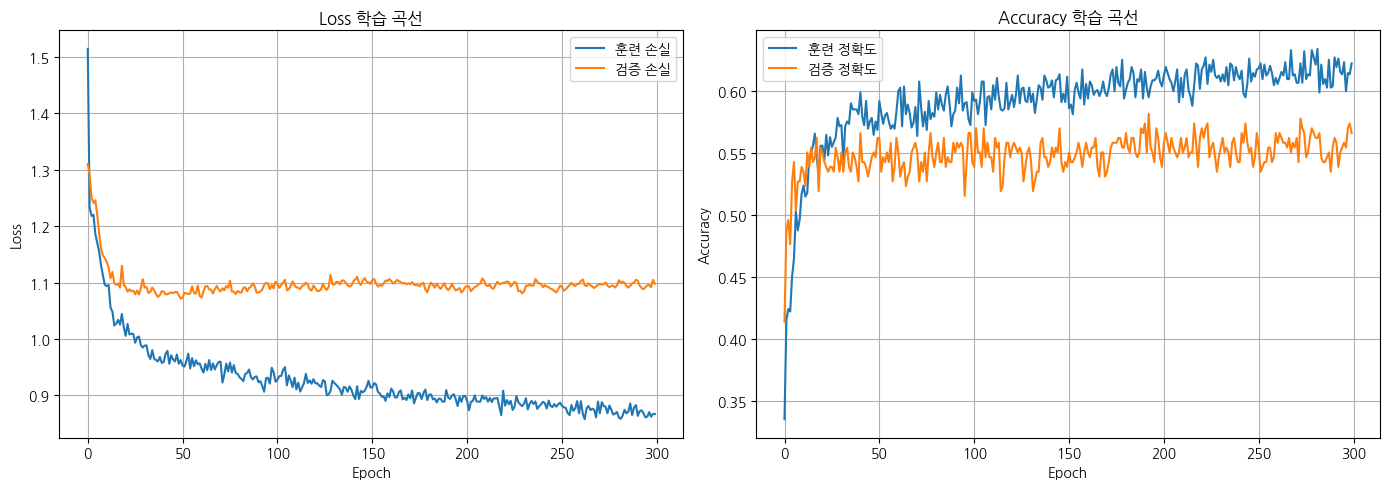

In [25]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 두번째 모델

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6442 - loss: 0.7854 - val_accuracy: 0.5820 - val_loss: 1.1201
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.7878 - val_accuracy: 0.5859 - val_loss: 1.1151
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6403 - loss: 0.7820 - val_accuracy: 0.5898 - val_loss: 1.1132
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6530 - loss: 0.7860 - val_accuracy: 0.5977 - val_loss: 1.1136
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6520 - loss: 0.8054 - val_accuracy: 0.5898 - val_loss: 1.1123
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6442 - loss: 0.7959 - val_accuracy: 0.5781 - val_loss: 1.1110
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6491 - loss: 0.7795 - val_accuracy: 0.5898 - val_loss: 1.1185
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6598 - loss: 0.7694 - val_accuracy: 0.5781 - val_loss:

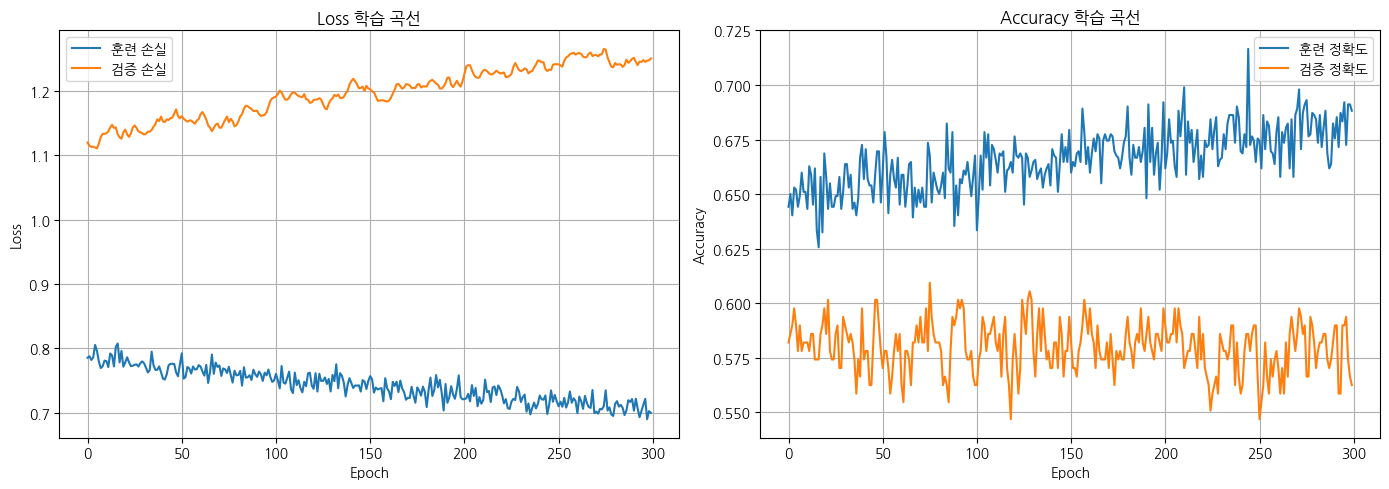

In [30]:
# 학습
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    verbose=1,
    validation_split=0.2
)

# 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 두번째 시각화

# 조기종료 적용 

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6784 - loss: 0.7140 - val_accuracy: 0.5977 - val_loss: 1.2547
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6843 - loss: 0.7074 - val_accuracy: 0.5820 - val_loss: 1.2571
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6970 - loss: 0.6900 - val_accuracy: 0.5625 - val_loss: 1.2630
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6989 - loss: 0.6973 - val_accuracy: 0.5625 - val_loss: 1.2669
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6843 - loss: 0.6971 - val_accuracy: 0.5820 - val_loss: 1.2658
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6999 - loss: 0.6857 - val_accuracy: 0.5664 - val_loss: 1.2653
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6813 - loss: 0.7075 - val_accuracy: 0.5781 - val_loss: 1.2591
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6823 - loss: 0.7089 - val_accuracy: 0.5938 - val_loss:

In [33]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 모델 새로 정의
model = Sequential()
model.add(Input(shape=(11,)))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(6, activation='softmax'))

# 컴파일
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# 학습
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.summary()

Epoch 1/300


I0000 00:00:1774578188.438874    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71482__.31
I0000 00:00:1774578188.914226    2432 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774578189.213875  102376 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 48 bytes spill stores, 48 bytes spill loads



1/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.1450 - loss: 2.6761

I0000 00:00:1774578191.546112    2433 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71482__.31


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.1370 - loss: 2.6270

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,908 (38.71 KB)

 Trainable params: 3,238 (12.65 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 6,478 (25.31 KB)

In [34]:
import pandas as pd
print(pd.Series(y_train).value_counts().sort_index())

0      8
1     42
2    545
3    510
4    159
5     15
Name: count, dtype: int64


# 조기종료 시각화

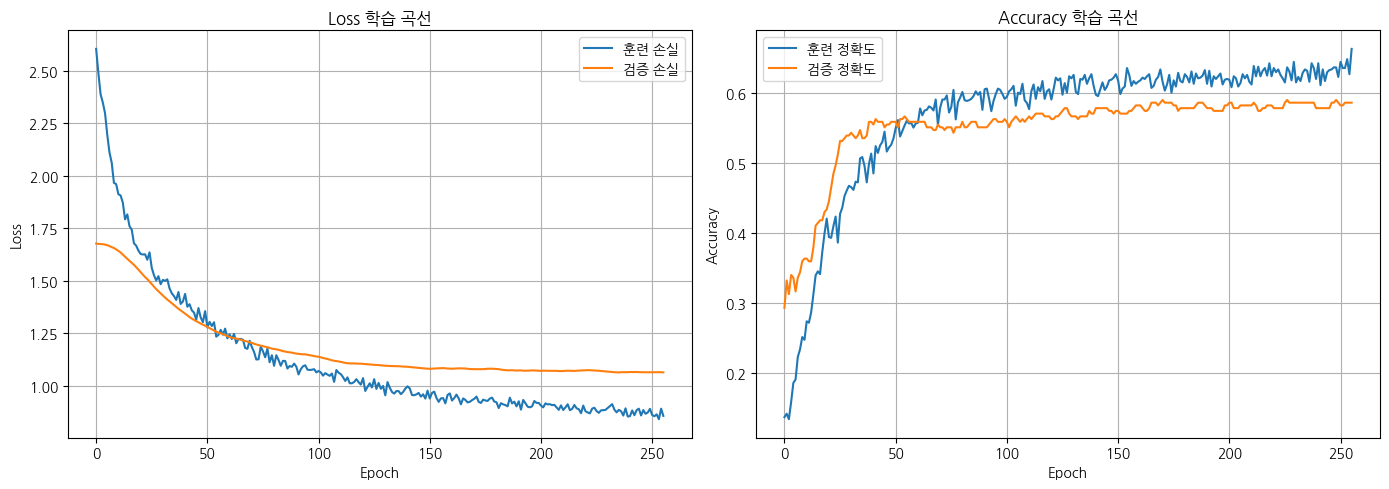

In [35]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 조기종료 적용 결과 검증

# model_es

In [41]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model_es = Sequential()
model_es.add(Input(shape=(11,))) #입력층
model_es.add(Dense(100, activation='sigmoid')) #은닉층1
model_es.add(Dropout(0.2))
model_es.add(Dense(200, activation='relu')) #은닉층2
model_es.add(Dropout(0.4))
model_es.add(Dense(50, activation='tanh')) #은닉층3
model_es.add(Dropout(0.1))
model_es.add(Dense(6, activation='softmax')) #출력층

In [42]:
from tensorflow.keras.optimizers import Adam
model_es.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history1 = model_es.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774581185.487530    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_113985__.17


1/6 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.2700 - loss: 1.7581

I0000 00:00:1774581189.946159    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_113985__.17


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 618ms/step - accuracy: 0.3803 - loss: 1.4820 - val_accuracy: 0.4219 - val_loss: 1.3113
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4242 - loss: 1.2749 - val_accuracy: 0.4062 - val_loss: 1.2864
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4438 - loss: 1.2257 - val_accuracy: 0.5195 - val_loss: 1.2203
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4555 - loss: 1.2112 - val_accuracy: 0.5156 - val_loss: 1.2078
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4868 - loss: 1.1693 - val_accuracy: 0.5117 - val_loss: 1.2155
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5112 - loss: 1.1372 - val_accuracy: 0.5117 - val_loss: 1.1827
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4848 - loss: 1.1169 - val_accuracy: 0.5117 - val_loss: 1.1543
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5161 - loss: 1.1160 - val_accuracy: 0.5547 - val_loss: 1.1412
Epo

In [44]:
plot_learning_curves(history1)

NameError: name 'plot_learning_curves' is not defined

# 활성화 함수 model build 함수

In [36]:
def build_model(activation1='sigmoid', activation2='relu', activation3='tanh'):
    model = Sequential()

    model.add(Input(shape=(11,)))

    model.add(Dense(100, activation=activation1))  # 은닉층 1
    model.add(Dropout(0.2))

    model.add(Dense(200, activation=activation2))  # 은닉층 2
    model.add(Dropout(0.4))

    model.add(Dense(50, activation=activation3))   # 은닉층 3
    model.add(Dropout(0.1))

    model.add(Dense(6, activation='softmax'))       # 출력층

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

# 활성화 함수 조합

In [37]:
# 기본 조합 (원래 설정)
model = build_model(activation1='sigmoid', activation2='relu', activation3='tanh')

# 전부 relu
model = build_model(activation1='relu', activation2='relu', activation3='relu')

# 전부 tanh
model = build_model(activation1='tanh', activation2='tanh', activation3='tanh')

# 혼합 실험
model = build_model(activation1='relu', activation2='tanh', activation3='sigmoid')

# 여러 조합 한번에 비교

In [38]:
combinations = [
    ('sigmoid', 'relu',    'tanh'),   # 원래 설정
    ('relu',    'relu',    'relu'),   # 전부 relu
    ('tanh',    'tanh',    'tanh'),   # 전부 tanh
    ('relu',    'tanh',    'relu'),   # 혼합
]

results = {}

for act1, act2, act3 in combinations:
    print(f"\n실험: {act1} / {act2} / {act3}")
    model = build_model(act1, act2, act3)
    history = model.fit(
        X_train_scaled_ary, y_train_ohe,
        epochs=50,
        batch_size=200,
        validation_split=0.2,
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    key = f"{act1}/{act2}/{act3}"
    results[key] = round(val_acc, 4)
    print(f"최고 검증 정확도: {val_acc:.4f}")

# 결과 비교
print("\n===== 실험 결과 비교 =====")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k:35s} → {v:.4f}")


실험: sigmoid / relu / tanh


I0000 00:00:1774579310.683666    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94125__.21
I0000 00:00:1774579312.548514    2433 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94125__.21


최고 검증 정확도: 0.5742

실험: relu / relu / relu


I0000 00:00:1774579321.508524    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99114__.21
I0000 00:00:1774579323.389061    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99114__.21
I0000 00:00:1774579325.630921    2432 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


최고 검증 정확도: 0.6016

실험: tanh / tanh / tanh


I0000 00:00:1774579331.911458    2431 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104103__.21
I0000 00:00:1774579333.776071    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104103__.21


최고 검증 정확도: 0.5781

실험: relu / tanh / relu


I0000 00:00:1774579341.088269    2430 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109092__.21
I0000 00:00:1774579342.895887    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109092__.21


최고 검증 정확도: 0.5938

===== 실험 결과 비교 =====
relu/relu/relu                      → 0.6016
relu/tanh/relu                      → 0.5938
tanh/tanh/tanh                      → 0.5781
sigmoid/relu/tanh                   → 0.5742


# 활성화 함수 결과 비교 시각화

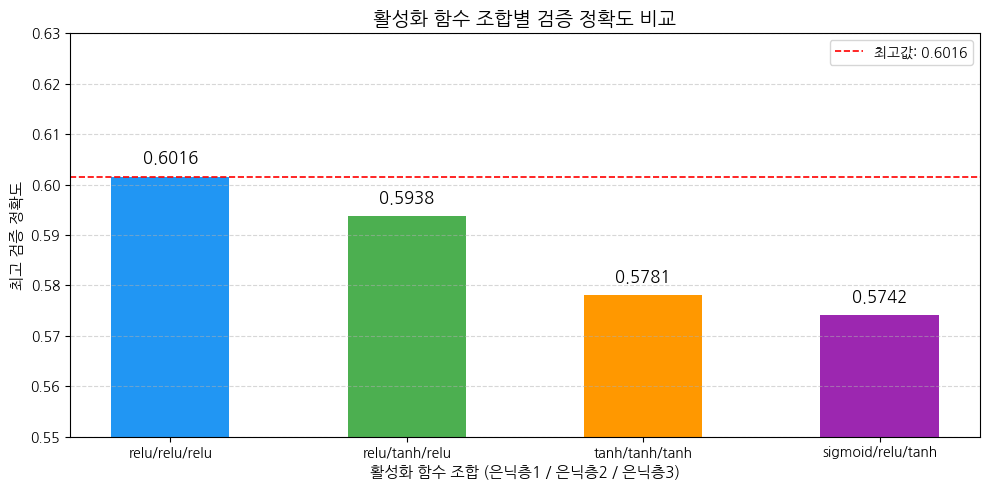

In [39]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 실험 결과
labels  = ['relu/relu/relu', 'relu/tanh/relu', 'tanh/tanh/tanh', 'sigmoid/relu/tanh']
scores  = [0.6016,            0.5938,            0.5781,            0.5742]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(labels, scores, color=colors, width=0.5)

# 막대 위에 수치 표시
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# 최고값 강조선
ax.axhline(y=max(scores), color='red', linestyle='--', linewidth=1.2, label=f'최고값: {max(scores)}')

ax.set_title('활성화 함수 조합별 검증 정확도 비교', fontsize=14)
ax.set_xlabel('활성화 함수 조합 (은닉층1 / 은닉층2 / 은닉층3)', fontsize=11)
ax.set_ylabel('최고 검증 정확도', fontsize=11)
ax.set_ylim(0.55, 0.63)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 활성화 함수 결과

In [40]:
import pandas as pd

df_results = pd.DataFrame({
    '순위':      [1, 2, 3, 4],
    '조합':      ['relu/relu/relu', 'relu/tanh/relu', 'tanh/tanh/tanh', 'sigmoid/relu/tanh'],
    '검증 정확도': ['60.16%', '59.38%', '57.81%', '57.42%'],
    '비고':      ['최고 성능', '근접한 성능', '보통', '최저 (원래 설정)']
})

df_results.set_index('순위', inplace=True)

df_results

,조합,검증 정확도,비고
순위,,,
1,relu/relu/relu,60.16%,최고 성능
2,relu/tanh/relu,59.38%,근접한 성능
3,tanh/tanh/tanh,57.81%,보통
4,sigmoid/relu/tanh,57.42%,최저 (원래 설정)


# batch normalization

In [48]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

model_br = Sequential()
model_br.add(Input(shape=(11,))) #입력층

model_br.add(Dense(100, activation='relu')) #은닉층1
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.2))

model_br.add(Dense(200, activation='relu')) #은닉층2
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.4))

model_br.add(Dense(50, activation='relu')) #은닉층3
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.1))

model_br.add(Dense(6, activation='softmax')) #출력층

from tensorflow.keras.optimizers import Adam
model_br.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# batch 정규화 학습

In [49]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history3 = model_br.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774581696.530543    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121664__.35


1/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.1800 - loss: 2.3315

I0000 00:00:1774581699.481925    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121664__.35


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.1928 - loss: 2.3745

I0000 00:00:1774581704.693410    2430 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774581705.061319    2430 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2082 - loss: 2.3292 - val_accuracy: 0.1836 - val_loss: 1.7897
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3539 - loss: 1.9307 - val_accuracy: 0.4023 - val_loss: 1.7114
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3978 - loss: 1.7233 - val_accuracy: 0.4531 - val_loss: 1.6500
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4585 - loss: 1.6615 - val_accuracy: 0.5039 - val_loss: 1.5944
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4761 - loss: 1.6008 - val_accuracy: 0.5000 - val_loss: 1.5438
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5239 - loss: 1.5259 - val_accuracy: 0.5156 - val_loss: 1.4980
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5249 - loss: 1.4662 - val_accuracy: 0.5352 - val_loss: 1.4611
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5445 - loss: 1.4095 - val_accuracy: 0.5391 - val_loss: 1.4285
Epoch

In [54]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

I0000 00:00:1774581847.027358    2431 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6156 - loss: 0.9883


In [55]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6156 - loss: 0.9883 
